In [3]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(ComplexHeatmap)
library(harmony)
library(ggsci)
library(ComplexHeatmap)
library(grid)
library(circlize)
library(scatterpie)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Loading required package: Rcpp

circlize version 0.4.16
CRAN page: https://cran.r-project.or

In [4]:
multi_colpalettes<-unique(c(pal_igv("default")(51),pal_npg("nrc")(10),pal_aaas("default")(10),pal_nejm("default")(8),pal_lancet("lanonc")(9),
                      pal_jama("default")(7),pal_jco("default")(10),pal_ucscgb("default")(26),pal_d3("category10")(10),
                      pal_locuszoom("default")(7),
                      pal_uchicago("default")(9),pal_startrek("uniform")(7),
                      pal_tron("legacy")(7),pal_futurama("planetexpress")(12),pal_rickandmorty("schwifty")(12),
                      pal_simpsons("springfield")(16),pal_gsea("default")(12)))
Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')

In [1]:
OG_gene <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups.tsv',sep='\t',row.names = 1)
OG_gene2 <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups_UnassignedGenes.tsv',sep='\t',row.names = 1)
OG_gene <- rbind(OG_gene,OG_gene2)

readRDS_process <- function(path){
    obj <- readRDS(path)
    obj@assays$RNA@meta.features <- OG_gene[rownames(obj@assays$RNA),]
    return(obj)
}

In [1]:
obj_EX <- readRDS('obj_GLU.rds')

In [5]:
intersection_OG <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_intersection_1028.csv',row.names = 1)
use_orthgroup <- intersection_OG[intersection_OG$Number>=5,'V1']

In [ ]:
#strategy 1: Use batch as batch
obj <- obj_EX
feature_num <- 2500
obj@active.assay <- 'RNA'

#Use the conserved orthgroup matrix
intersection_OG <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_intersection_1028.csv',row.names = 1)
use_orthgroup <- intersection_OG[intersection_OG$Number>=5,'V1']
raw_assays <- obj[['RNA']]@counts
obj <- CreateSeuratObject(obj@assays$RNA@counts[rownames(obj)%in%use_orthgroup,],meta.data=obj@meta.data)

#Integrated batch
obj@meta.data$integrated_batch <- obj@meta.data$batch

obj.list <- lapply(unique(obj$integrated_batch),function(x){return(obj[,obj$integrated_batch==x])})
obj.list <- lapply(X = obj.list, FUN = SCTransform)
features <- SelectIntegrationFeatures(object.list = obj.list,nfeatures = feature_num)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)
obj.anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT", k.anchor = 20,
                                              reference = grep(FALSE,duplicated(gsub('_.*','',unique(obj$integrated_batch)))),anchor.features = features)
obj <- IntegrateData(anchorset = obj.anchors, normalization.method = "SCT",k.weight = 100)

obj[['RNA']] <- CreateAssayObject(raw_assays[,colnames(obj)])

#Run seurat pipline
DefaultAssay(obj) <- "integrated"
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)
saveRDS(obj,'obj_GLU_integrated.rds')

#Delete the cluster like IN neuron
DefaultAssay(obj) <- "integrated"
obj <- obj[,obj$integrated_snn_res.0.5!=6]
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)

#Annotation
obj$Subclass <- 'None'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(0,7),]$Subclass <- 'Upper-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(1,3,11,13),]$Subclass <- 'Middle-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(5,6,4,12),]$Subclass <- 'Deep-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(2),]$Subclass <- 'Deep-CT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(10),]$Subclass <- 'Deep-PT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(8),]$Subclass <- 'Deep-NP'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(9),]$Subclass <- 'Deep-RGS12'

obj@assays$RNA@meta.features <- OG_gene[rownames(obj),]

saveRDS(obj,'obj_GLU_integrated_final_20251114.rdsobj_GLU_integrated_final_20251114.rds')

In [119]:
#strategy 2: Use species as batch
obj <- obj_EX
feature_num <- 2500
obj@active.assay <- 'RNA'

#Use the conserved orthgroup matrix
intersection_OG <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_intersection_1028.csv',row.names = 1)
use_orthgroup <- intersection_OG[intersection_OG$Number>=5,'V1']
raw_assays <- obj[['RNA']]@counts
obj <- CreateSeuratObject(obj@assays$RNA@counts[rownames(obj)%in%use_orthgroup,],meta.data=obj@meta.data)

#Integrated batch
obj@meta.data$integrated_batch <- obj@meta.data$species

obj.list <- lapply(unique(obj$integrated_batch),function(x){return(obj[,obj$integrated_batch==x])})
obj.list <- lapply(X = obj.list, FUN = SCTransform)
features <- SelectIntegrationFeatures(object.list = obj.list,nfeatures = feature_num)
obj.list <- PrepSCTIntegration(object.list = obj.list, anchor.features = features)
obj.anchors <- FindIntegrationAnchors(object.list = obj.list, normalization.method = "SCT", k.anchor = 20,
                                              reference = grep(FALSE,duplicated(gsub('_.*','',unique(obj$integrated_batch)))),anchor.features = features)
obj <- IntegrateData(anchorset = obj.anchors, normalization.method = "SCT",k.weight = 100)

obj[['RNA']] <- CreateAssayObject(raw_assays[,colnames(obj)])
#Run seurat pipline
DefaultAssay(obj) <- "integrated"
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:15,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)

saveRDS(obj,'obj_GLU_integrated.rds')

#Delete the cluster like IN neuron
obj <- obj[,obj$integrated_snn_res.0.5!=10]
DefaultAssay(obj) <- "integrated"
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj,verbose=F)
obj <- RunHarmony(obj,verbose = F,reduction.use = 'pca',group.by.vars = 'batch')
obj <- RunUMAP(obj,reduction = 'harmony',dims=1:13,verbose = F,n.neighbors = 50)
obj <- FindNeighbors(obj,reduction = 'harmony',dims=1:13,verbose = F)
obj <- FindClusters(obj,verbose = F,resolution=0.5)

#Annotation
obj$Subclass <- 'None'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(1,4,5),]$Subclass <- 'Upper-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(2,7,12),]$Subclass <- 'Middle-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(0,6),]$Subclass <- 'Deep-IT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(3,11),]$Subclass <- 'Deep-CT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(10),]$Subclass <- 'Deep-PT'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(9),]$Subclass <- 'Deep-NP'
obj@meta.data[obj@meta.data$integrated_snn_res.0.5%in%c(8),]$Subclass <- 'Deep-RGS12'

obj@assays$RNA@meta.features <- OG_gene[rownames(obj),]

saveRDS(obj,'obj_GLU_integrated_final_20251114.rdsobj_GLU_integrated_final_20251118.rds')

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 11845 by 26626

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 2 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 11845 genes



  |======================================================================| 100%


Computing corrected count matrix for 11845 genes



...

Found 42 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 11400 genes



  |======================================================================| 100%


Computing corrected count matrix for 11400 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 1.018449 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT

Finding anchors between all query and reference datasets

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 267844 anchors

Filtering anchors

	Retained 79096 anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 246456 anchors

Filtering anchors

	Retained 42608 anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the a

In [2]:
obj_EX_SCT <- readRDS('obj_GLU_integrated.rds')

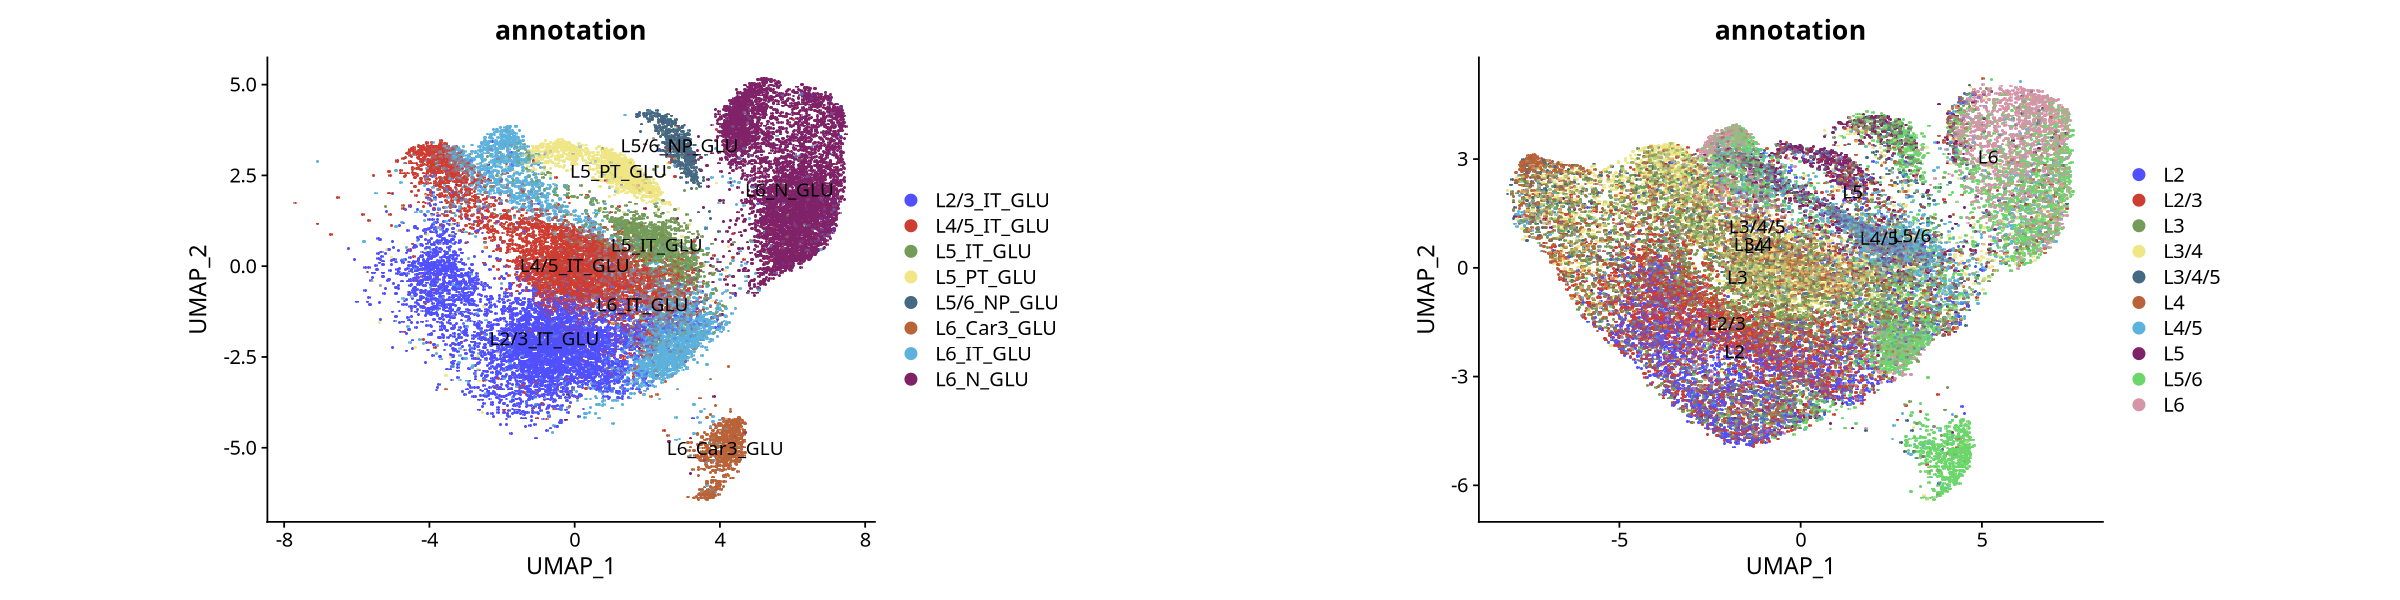

In [183]:
options(repr.plot.height=5,repr.plot.width=20)
DimPlot(obj_EX_SCT[,obj_EX_SCT$species=='mous'&grepl('L2|L3|L4|L5|L6',obj_EX_SCT$annotation)],reduction = 'umap',group.by='annotation',pt.size =2,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed()|
DimPlot(obj_EX_SCT[,obj_EX_SCT$species=='marm'&grepl('L2|L3|L4|L5|L6',obj_EX_SCT$annotation)],reduction = 'umap',group.by='annotation',pt.size =2,raster = T,label=T)+
scale_color_manual(values = multi_colpalettes)+
coord_fixed()

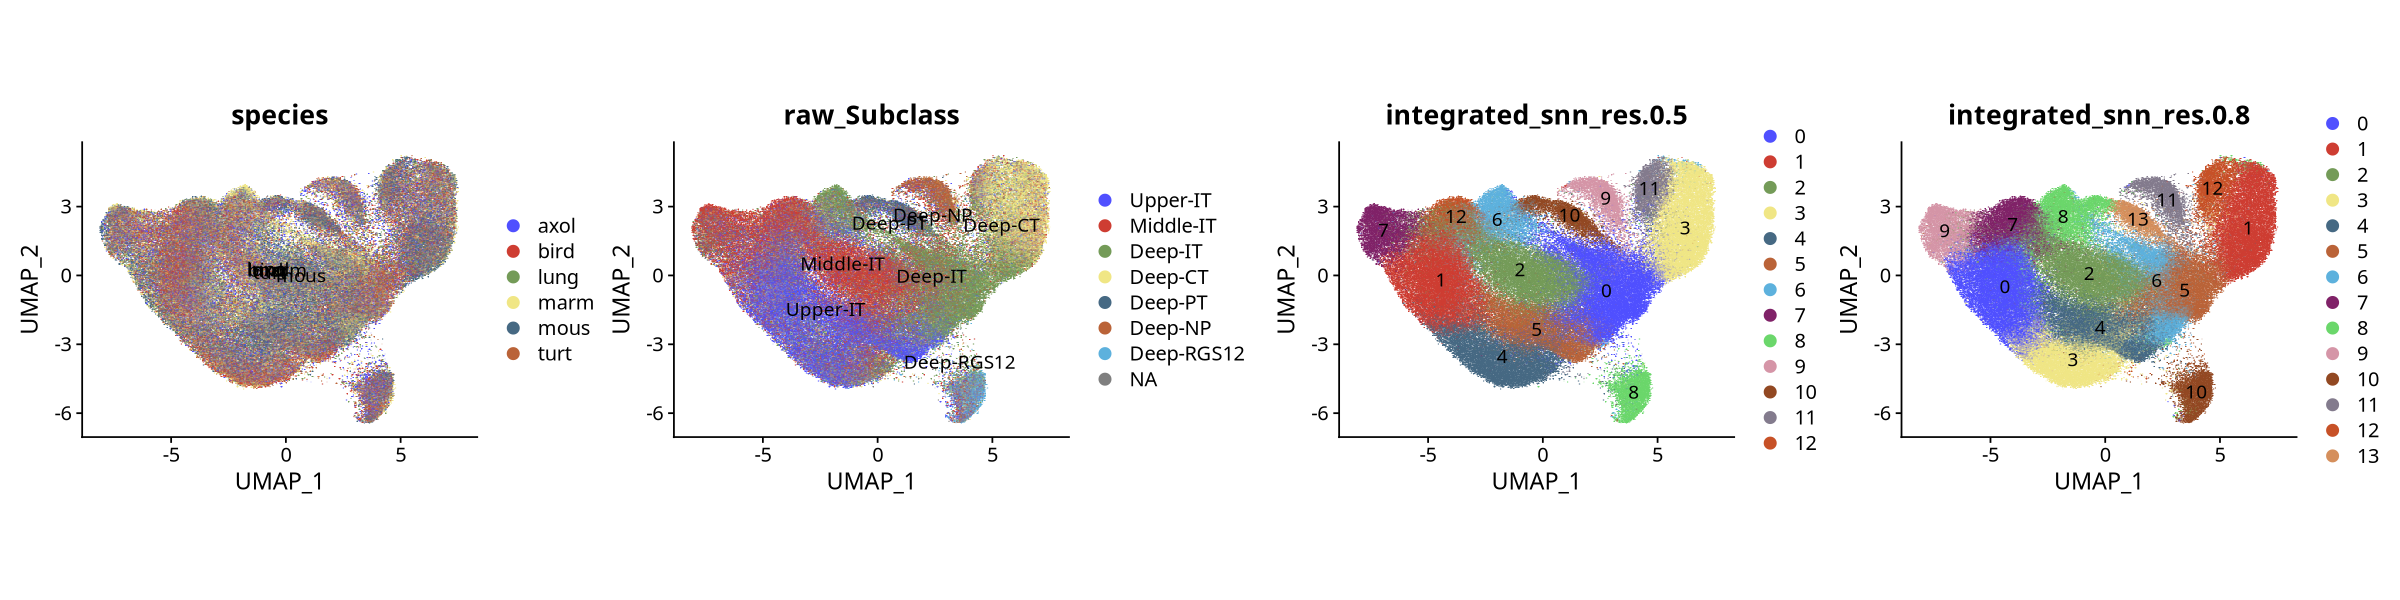

In [188]:
options(repr.plot.height=5,repr.plot.width=20)
DimPlot(obj_EX_SCT,reduction = 'umap',group.by='species',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()|
DimPlot(obj_EX_SCT,reduction = 'umap',group.by='raw_Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()|
DimPlot(obj_EX_SCT,reduction = 'umap',group.by='integrated_snn_res.0.5',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()|
DimPlot(obj_EX_SCT,reduction = 'umap',group.by='integrated_snn_res.0.8',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()

In [184]:
obj_EX_SCT$Subclass <- 'None'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(1,4,5),]$Subclass <- 'Upper-IT'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(2,7,12),]$Subclass <- 'Middle-IT'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(0,6),]$Subclass <- 'Deep-IT'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(3,11),]$Subclass <- 'Deep-CT'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(10),]$Subclass <- 'Deep-PT'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(9),]$Subclass <- 'Deep-NP'
obj_EX_SCT@meta.data[obj_EX_SCT@meta.data$integrated_snn_res.0.5%in%c(8),]$Subclass <- 'Deep-RGS12'

#obj_EX_SCT@meta.data$Subclass <- c('PV'='MGE.PVALB','PV-CHC'='MGE.PVALB-POSTN','SST'='MGE.SST',
#                         'VIP'='CGE.VIP','LAMP5'='CGE.LAMP5','LAMP5-RELN'='CGE.LAMP5-RELN','RELN'='CGE.RELN','CGE-MEIS2'='CGE.MEIS2',
#                         'MEIS2-TSHZ1'='LGE.TSHZ1','MEIS2-FOXP1'='LGE.FOXP1')[obj_EX_SCT$Subclass]

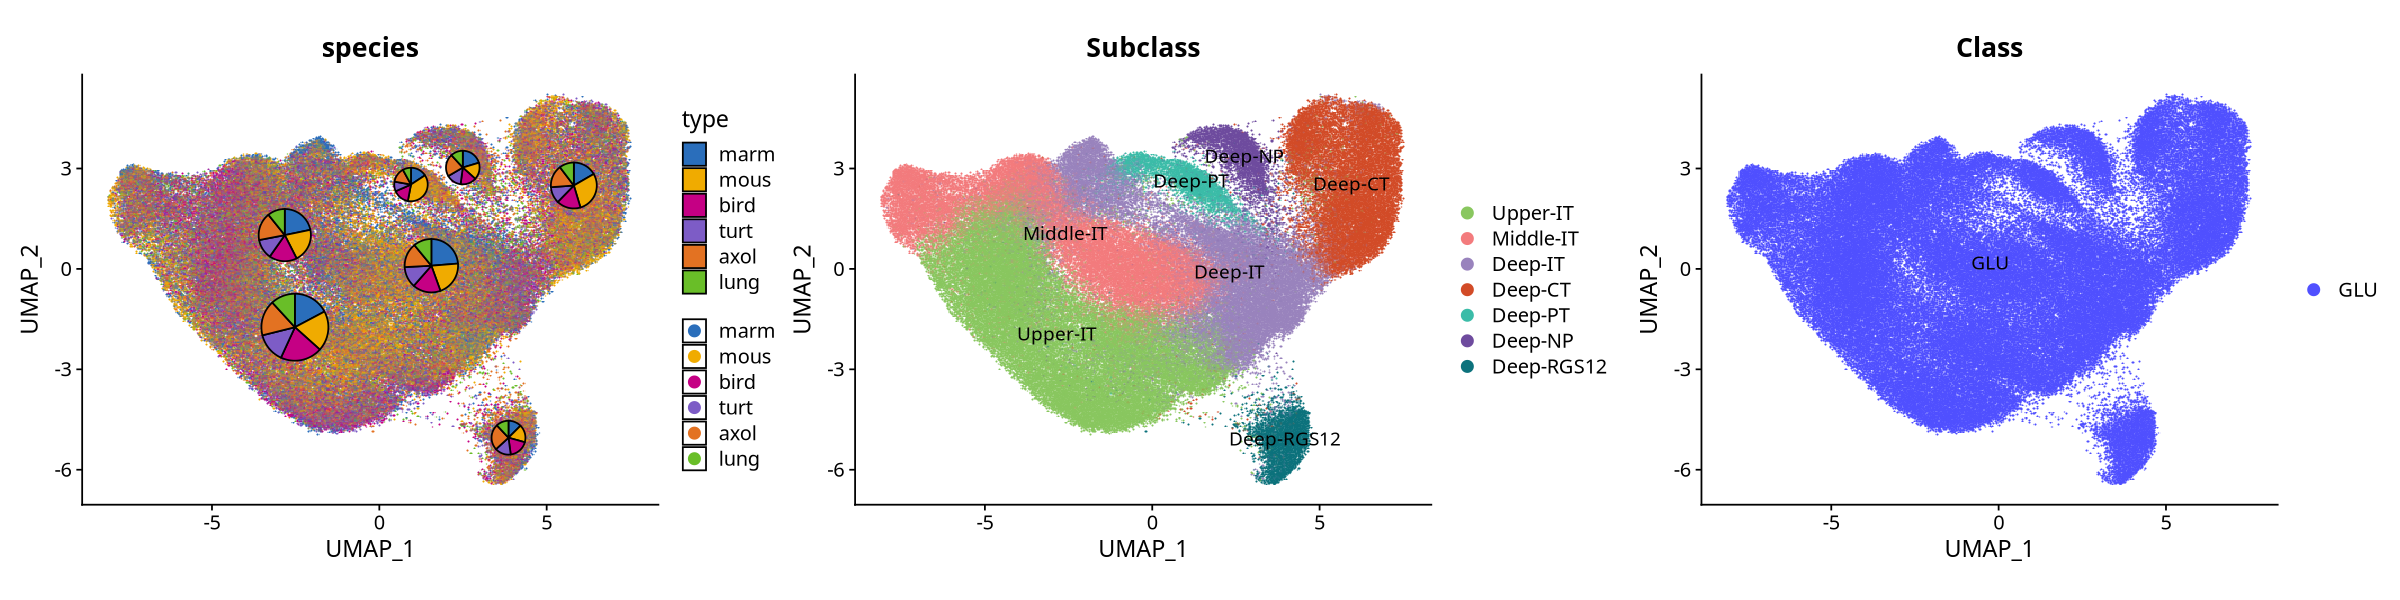

In [205]:
options(repr.plot.height=5,repr.plot.width=20)
obj_tmp <- obj_EX_SCT
piedf <- aggregate(list('UMAP1'=obj_tmp@reductions$umap@cell.embeddings[,1],'UMAP2'=obj_tmp@reductions$umap@cell.embeddings[,2]),by=list('Subclass'=obj_tmp$Subclass),mean)
piedf <- cbind(as.data.frame.array(table(obj_tmp@meta.data[,c('Subclass','species')])),piedf)
piedf$radius <- as.numeric(table(obj_tmp$Subclass))
piedf$radius <- (((piedf$radius-min(piedf$radius))/(max(piedf$radius)-min(piedf$radius)))+1)/2

p1 <- DimPlot(obj_tmp,reduction = 'umap',group.by='species',pt.size = 1.5,raster = T,label=F)+
geom_scatterpie(data=piedf,aes(x=UMAP1,y=UMAP2,r=radius),lwd=0.5,cols=c('marm','mous','bird','turt','axol','lung'),show.legend = TRUE)+
scale_color_manual(values = c(pal_bmj()(6)),breaks = c('marm','mous','bird','turt','axol','lung'))+
scale_fill_manual(values = c(pal_bmj()(6)),breaks = c('marm','mous','bird','turt','axol','lung'))+
coord_fixed()
p2 <- DimPlot(obj_tmp,reduction = 'umap',group.by='Subclass',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = Archr_col[11:19])+
coord_fixed()
p3 <- DimPlot(obj_tmp,reduction = 'umap',group.by='Class',pt.size = 1.5,raster = T,label=T)+
scale_color_manual(values = c(ggsci::pal_igv()(50)))+
coord_fixed()
p1|p2|p3

In [206]:
pdf('Plot/EX_UMAP_subclass.pdf',height=5,width=20)
p1|p2
dev.off()

pdf 
  2

In [194]:
obj_EX_SCT@active.assay <- 'RNA'
obj_EX_SCT <- NormalizeData(obj_EX_SCT)

In [196]:
Idents(obj_EX_SCT) <- 'Subclass'
Marker_list <- FindAllMarkers(obj_EX_SCT,slot='data',assay = 'RNA')

Calculating cluster Upper-IT

Calculating cluster Middle-IT

Calculating cluster Deep-IT

Calculating cluster Deep-CT

Calculating cluster Deep-PT

Calculating cluster Deep-NP

Calculating cluster Deep-RGS12



In [197]:
saveRDS(Marker_list,'obj_GLU.markerlist.rds')

In [208]:
saveRDS(obj_EX_SCT,'obj_GLU_integrated_final_20251118.rds')